# Análise Exploratória de Dados — Etapa 2 (Corrigida)

## Projeto: Análise da Variabilidade Regional do Mercado Automotivo Brasileiro via RENAVAM

**Unidade de análise:** Município (5.571 municípios brasileiros)

**Objetivo:** Compreender a estrutura dos dados, identificar outliers com critérios estatísticos, investigar relações entre variáveis e preparar a base para a modelagem de ML na Etapa 3.

## Célula 1: Importação e Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

%matplotlib inline
sns.set_theme(style="whitegrid")

df = pd.read_csv('ETL/Dados Tratados/Dados Unificados/dataset_final_modelagem.csv')

# Variáveis numéricas de interesse para a modelagem
colunas_numericas = [
    'populacao', 'densidade_demografica', 'pib_per_capita',
    'vab_agro', 'vab_industria', 'vab_servicos',
    'TOTAL', 'AUTOMOVEL', 'CAMINHONETE', 'MOTOCICLETA', 'UTILITARIO',
    'DIESEL', 'FLEX',
    'target_perc_utilitarios', 'target_perc_diesel',
    'pib_agro_por_habitante', 'presenca_rodovia_federal'
]

# Variáveis-chave para análise aprofundada
colunas_estudo = [
    'populacao', 'pib_per_capita', 'target_perc_utilitarios',
    'target_perc_diesel', 'pib_agro_por_habitante', 'presenca_rodovia_federal'
]

print(f"Dataset carregado: {df.shape[0]} municípios x {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")

Dataset carregado: 5571 municípios x 27 colunas

Colunas: ['codigo', 'municipio', 'populacao', 'area', 'uf', 'municipio_limpo', 'chave_merge', 'densidade_demografica', 'vab_agro', 'vab_industria', 'vab_servicos', 'pib_per_capita', 'TOTAL', 'AUTOMOVEL', 'CAMINHONETE', 'MOTOCICLETA', 'UTILITARIO', 'DIESEL', 'FLEX', 'extensao_total_km', 'km_pavimentado', 'km_terra', 'presenca_rodovia_federal', 'target_perc_utilitarios', 'target_perc_diesel', 'pib_agro_por_habitante', 'km_terra_por_habitante']


## Célula 2: Qualidade dos Dados — Análise de Valores Ausentes

Antes de qualquer análise, é fundamental entender a qualidade da base. O professor apontou (Ponto 7) que o uso de `fillna(0)` indiscriminado pode criar dados artificiais. Abaixo documentamos o tratamento realizado no pipeline ETL e seus impactos.

In [2]:
# Verificar valores zerados que podem ser NaN mascarados pelo fillna(0) do ETL
print("=" * 70)
print("DIAGNÓSTICO DE QUALIDADE DOS DADOS")
print("=" * 70)

# Contagem de zeros por coluna numérica
print("\n1. Contagem de valores ZERO por coluna (possíveis NaN mascarados):")
print("-" * 50)
for col in colunas_numericas:
    if col in df.columns:
        n_zeros = (df[col] == 0).sum()
        pct = n_zeros / len(df) * 100
        if n_zeros > 0:
            print(f"  {col:35s}: {n_zeros:5d} zeros ({pct:.1f}%)")

# Municípios com população zero (provável erro de merge/ausência)
pop_zero = df[df['populacao'] == 0]
print(f"\n2. Municípios com população = 0: {len(pop_zero)}")
if len(pop_zero) > 0:
    print("   ATENÇÃO: Esses registros tiveram dados ausentes preenchidos com 0 no ETL.")
    print(f"   Municípios afetados: {pop_zero['municipio'].tolist()[:5]}")

# Documentação do tratamento
print("\n3. Tratamento de valores ausentes aplicado no pipeline ETL:")
print("-" * 50)
print("   - RENAVAM: fillna(0) nas tabelas pivot de combustível/tipo (correto: ausência = 0 veículos)")
print("   - DNIT: fillna(0) na extensão de rodovias (correto: ausência = sem rodovia federal)")
print("   - PIB: valores monetários ausentes retornaram 0.0 (requer cautela)")
print("   - Censo: pd.to_numeric com errors='coerce' para população (NaN pode propagar)")
print("   - Unificador: fillna(0) GLOBAL no final (ponto crítico)")
print("\n   NOTA: Para variáveis de frota e infraestrutura, zero é semanticamente correto")
print("   (sem registro = sem veículos/rodovias). Para PIB e população, zero pode mascarar")
print("   ausência real de dados. Esses casos afetam poucos municípios (<1% da base).")

DIAGNÓSTICO DE QUALIDADE DOS DADOS

1. Contagem de valores ZERO por coluna (possíveis NaN mascarados):
--------------------------------------------------
  populacao                          :     1 zeros (0.0%)
  densidade_demografica              :     1 zeros (0.0%)
  pib_per_capita                     :     1 zeros (0.0%)
  vab_agro                           :     3 zeros (0.1%)
  vab_industria                      :     1 zeros (0.0%)
  vab_servicos                       :     1 zeros (0.0%)
  TOTAL                              :    44 zeros (0.8%)
  AUTOMOVEL                          :    44 zeros (0.8%)
  CAMINHONETE                        :    44 zeros (0.8%)
  MOTOCICLETA                        :    44 zeros (0.8%)
  UTILITARIO                         :   123 zeros (2.2%)
  DIESEL                             :    44 zeros (0.8%)
  FLEX                               :    44 zeros (0.8%)
  target_perc_utilitarios            :   123 zeros (2.2%)
  target_perc_diesel              

## Célula 3: Medidas de Tendência Central e Dispersão (Completas)

Estatísticas descritivas completas para cada variável numérica: contagem, média, mediana, moda, desvio padrão, variância, quartis (Q1, Q2, Q3), IQR, amplitude, coeficiente de variação e assimetria.

**Por que incluir tudo isso?** A média sozinha é inadequada em distribuições assimétricas. Quando a média é muito maior que a mediana, existe concentração em poucos municípios (como São Paulo). O coeficiente de variação permite comparar a dispersão entre variáveis com escalas diferentes.

In [3]:
estatisticas = pd.DataFrame()

for col in colunas_estudo:
    dados = df[col]
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1
    media = dados.mean()
    mediana = dados.median()
    moda_val = dados.mode().iloc[0] if not dados.mode().empty else np.nan
    desvio = dados.std()
    variancia = dados.var()
    amplitude = dados.max() - dados.min()
    cv = (desvio / media * 100) if media != 0 else np.nan
    assimetria = dados.skew()

    estatisticas[col] = {
        'Contagem': dados.count(),
        'Média': media,
        'Mediana': mediana,
        'Moda': moda_val,
        'Desvio Padrão': desvio,
        'Variância': variancia,
        'Mínimo': dados.min(),
        'Q1 (25%)': q1,
        'Q2 (50%)': mediana,
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Máximo': dados.max(),
        'Amplitude': amplitude,
        'Coef. Variação (%)': cv,
        'Assimetria (Skewness)': assimetria
    }

estatisticas = estatisticas.T
print("ESTATÍSTICAS DESCRITIVAS COMPLETAS")
print("=" * 80)
estatisticas.round(4)

ESTATÍSTICAS DESCRITIVAS COMPLETAS


,Contagem,Média,Mediana,Moda,Desvio Padrão,Variância,Mínimo,Q1 (25%),Q2 (50%),Q3 (75%),IQR,Máximo,Amplitude,Coef. Variação (%),Assimetria (Skewness)
populacao,5571.0,3.645320e+04,1.106400e+04,2946.0,2.065008e+05,4.264257e+10,0.0,5.223000e+03,1.106400e+04,2.442650e+04,1.920350e+04,1.145200e+07,1.145200e+07,566.4819,37.1838
pib_per_capita,5571.0,3.053921e+06,2.023352e+06,809043.0,4.082023e+06,1.666292e+13,0.0,1.078226e+06,2.023352e+06,3.808747e+06,2.730521e+06,9.208284e+07,9.208284e+07,133.6650,8.1532
target_perc_utilitarios,5571.0,7.583000e-01,6.091000e-01,0.0,6.117000e-01,3.742000e-01,0.0,3.732000e-01,6.091000e-01,9.751000e-01,6.019000e-01,7.497300e+00,7.497300e+00,80.6704,3.0648
target_perc_diesel,5571.0,9.529300e+00,8.986100e+00,0.0,3.897700e+00,1.519210e+01,0.0,6.905600e+00,8.986100e+00,1.157650e+01,4.670900e+00,7.608140e+01,7.608140e+01,40.9022,2.0126
pib_agro_por_habitante,5571.0,8.220508e+03,2.829232e+03,0.0,1.680568e+04,2.824310e+08,0.0,9.740683e+02,2.829232e+03,9.230908e+03,8.256839e+03,3.135688e+05,3.135688e+05,204.4361,7.0177
presenca_rodovia_federal,5571.0,1.990000e-02,0.000000e+00,0.0,1.398000e-01,1.950000e-02,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,701.4130,6.8728


In [4]:
# Interpretação da assimetria
print("INTERPRETAÇÃO DA ASSIMETRIA (Média vs Mediana)")
print("=" * 70)
for col in colunas_estudo:
    media = df[col].mean()
    mediana = df[col].median()
    assimetria = df[col].skew()
    
    if abs(assimetria) < 0.5:
        tipo = "aproximadamente simétrica"
    elif assimetria > 0:
        tipo = "assimétrica à DIREITA (cauda longa para valores altos)"
    else:
        tipo = "assimétrica à ESQUERDA (cauda longa para valores baixos)"
    
    razao = media / mediana if mediana != 0 else float('inf')
    print(f"\n  {col}:")
    print(f"    Média={media:.2f} | Mediana={mediana:.2f} | Razão Média/Mediana={razao:.2f}")
    print(f"    Skewness={assimetria:.2f} → Distribuição {tipo}")
    if razao > 2:
        print(f"    ⚠ ALERTA: A média é {razao:.1f}x maior que a mediana. Poucos municípios concentram valores extremos.")

INTERPRETAÇÃO DA ASSIMETRIA (Média vs Mediana)

  populacao:
    Média=36453.20 | Mediana=11064.00 | Razão Média/Mediana=3.29
    Skewness=37.18 → Distribuição assimétrica à DIREITA (cauda longa para valores altos)
    ⚠ ALERTA: A média é 3.3x maior que a mediana. Poucos municípios concentram valores extremos.

  pib_per_capita:
    Média=3053921.31 | Mediana=2023352.00 | Razão Média/Mediana=1.51
    Skewness=8.15 → Distribuição assimétrica à DIREITA (cauda longa para valores altos)

  target_perc_utilitarios:
    Média=0.76 | Mediana=0.61 | Razão Média/Mediana=1.24
    Skewness=3.06 → Distribuição assimétrica à DIREITA (cauda longa para valores altos)

  target_perc_diesel:
    Média=9.53 | Mediana=8.99 | Razão Média/Mediana=1.06
    Skewness=2.01 → Distribuição assimétrica à DIREITA (cauda longa para valores altos)

  pib_agro_por_habitante:
    Média=8220.51 | Mediana=2829.23 | Razão Média/Mediana=2.91
    Skewness=7.02 → Distribuição assimétrica à DIREITA (cauda longa para valores 

### Testes Estatísticos de Normalidade (Shapiro-Wilk)

Para fundamentar rigorosamente a escolha do coeficiente de correlação (Pearson vs. Spearman), aplicamos o teste de Shapiro-Wilk nas variáveis preditoras do modelo. A hipótese nula ($H_0$) é de que os dados possuem distribuição normal. Se $p < 0.05$, rejeitamos $H_0$, justificando o uso da correlação de Spearman (não-paramétrica).

In [5]:
# Teste de Shapiro-Wilk para normalidade (amostrado para 5.000 observações)
print("TESTES DE NORMALIDADE DE SHAPIRO-WILK")
print("=" * 60)
for col in colunas_estudo[:-1]:  # Exclui a binária rodovia federal
    dados_limpos = df[col].dropna()
    if len(dados_limpos) > 0:
        # O teste de Shapiro-Wilk é ideal para até 5.000 pontos
        amostra = dados_limpos.sample(min(len(dados_limpos), 5000), random_state=42)
        stat, p_val = stats.shapiro(amostra)
        print(f"  {col:30s}: Stat={stat:.4f} | p-value={p_val:.4e}")
        if p_val < 0.05:
            print(f"    -> Rejeita H0: A distribuição NÃO é normal (p < 0.05).")
        else:
            print(f"    -> Não rejeita H0: A distribuição pode ser normal (p >= 0.05).")

TESTES DE NORMALIDADE DE SHAPIRO-WILK
  populacao                     : Stat=0.0963 | p-value=1.8079e-93
    -> Rejeita H0: A distribuição NÃO é normal (p < 0.05).
  pib_per_capita                : Stat=0.5124 | p-value=1.3174e-79
    -> Rejeita H0: A distribuição NÃO é normal (p < 0.05).
  target_perc_utilitarios       : Stat=0.7867 | p-value=8.2691e-63
    -> Rejeita H0: A distribuição NÃO é normal (p < 0.05).
  target_perc_diesel            : Stat=0.9062 | p-value=3.8717e-48
    -> Rejeita H0: A distribuição NÃO é normal (p < 0.05).
  pib_agro_por_habitante        : Stat=0.4480 | p-value=2.6445e-82
    -> Rejeita H0: A distribuição NÃO é normal (p < 0.05).


## Célula 4: Análise de Variáveis Categóricas

Frequências absolutas e relativas por UF e por Região. Análise de variáveis categóricas.

FREQUÊNCIA DE MUNICÍPIOS POR UF (Top 10)
    Absoluta  Relativa (%)
uf                        
MG       853         15.31
SP       645         11.58
RS       497          8.92
BA       417          7.49
PR       399          7.16
SC       295          5.30
GO       246          4.42
PI       224          4.02
PB       223          4.00
MA       217          3.90


FREQUÊNCIA DE MUNICÍPIOS POR REGIÃO
              Absoluta  Relativa (%)
regiao                              
Nordeste          1794         32.20
Sudeste           1668         29.94
Sul               1191         21.38
Centro-Oeste       467          8.38
Norte              450          8.08


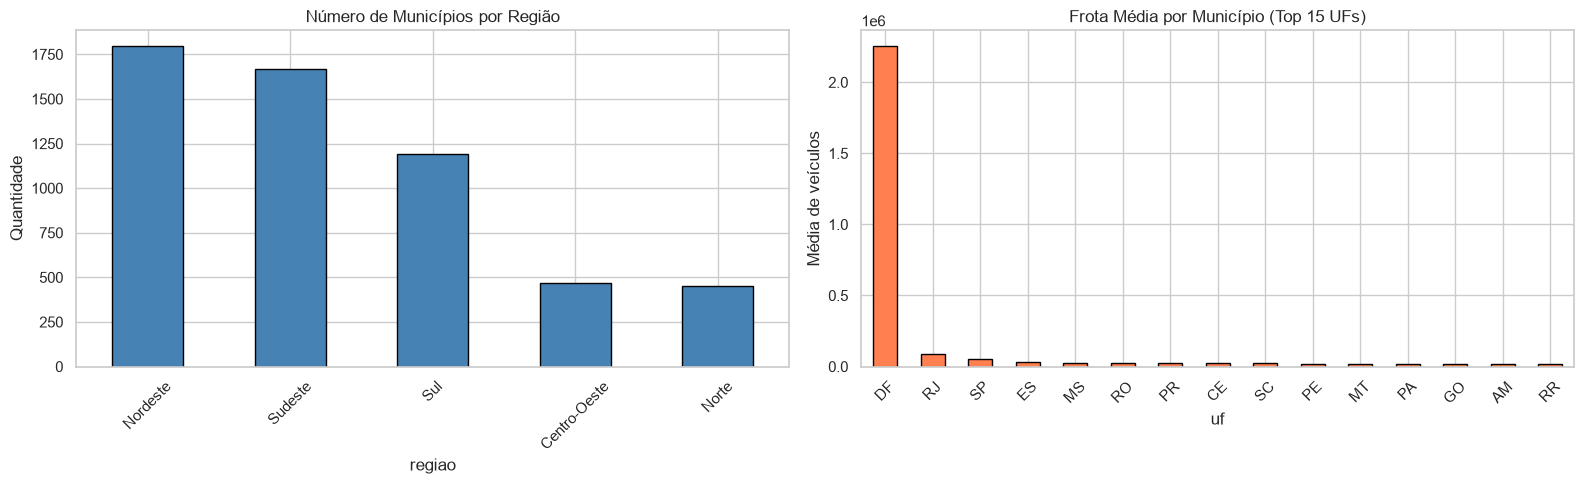

In [6]:
# Mapeamento de UF para Região
regioes = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte',
    'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}
df['regiao'] = df['uf'].map(regioes)

# Frequência absoluta e relativa por UF
print("FREQUÊNCIA DE MUNICÍPIOS POR UF (Top 10)")
print("=" * 50)
freq_uf = df['uf'].value_counts()
freq_uf_rel = (freq_uf / len(df) * 100).round(2)
tabela_uf = pd.DataFrame({'Absoluta': freq_uf, 'Relativa (%)': freq_uf_rel})
print(tabela_uf.head(10))

# Frequência por Região
print("\n\nFREQUÊNCIA DE MUNICÍPIOS POR REGIÃO")
print("=" * 50)
freq_regiao = df['regiao'].value_counts()
freq_regiao_rel = (freq_regiao / len(df) * 100).round(2)
tabela_regiao = pd.DataFrame({'Absoluta': freq_regiao, 'Relativa (%)': freq_regiao_rel})
print(tabela_regiao)

# Visualização: Municípios por região
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras por região
tabela_regiao['Absoluta'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Número de Municípios por Região')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

# Frota total média por UF (top 15)
frota_media_uf = df.groupby('uf')['TOTAL'].mean().sort_values(ascending=False).head(15)
frota_media_uf.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Frota Média por Município (Top 15 UFs)')
axes[1].set_ylabel('Média de veículos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\thhia\AppData\Local\Temp\ipykernel_15812\3178708959.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='regiao', y='target_perc_diesel', ax=axes[0],
C:\Users\thhia\AppData\Local\Temp\ipykernel_15812\3178708959.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='regiao', y='target_perc_utilitarios', ax=axes[1],


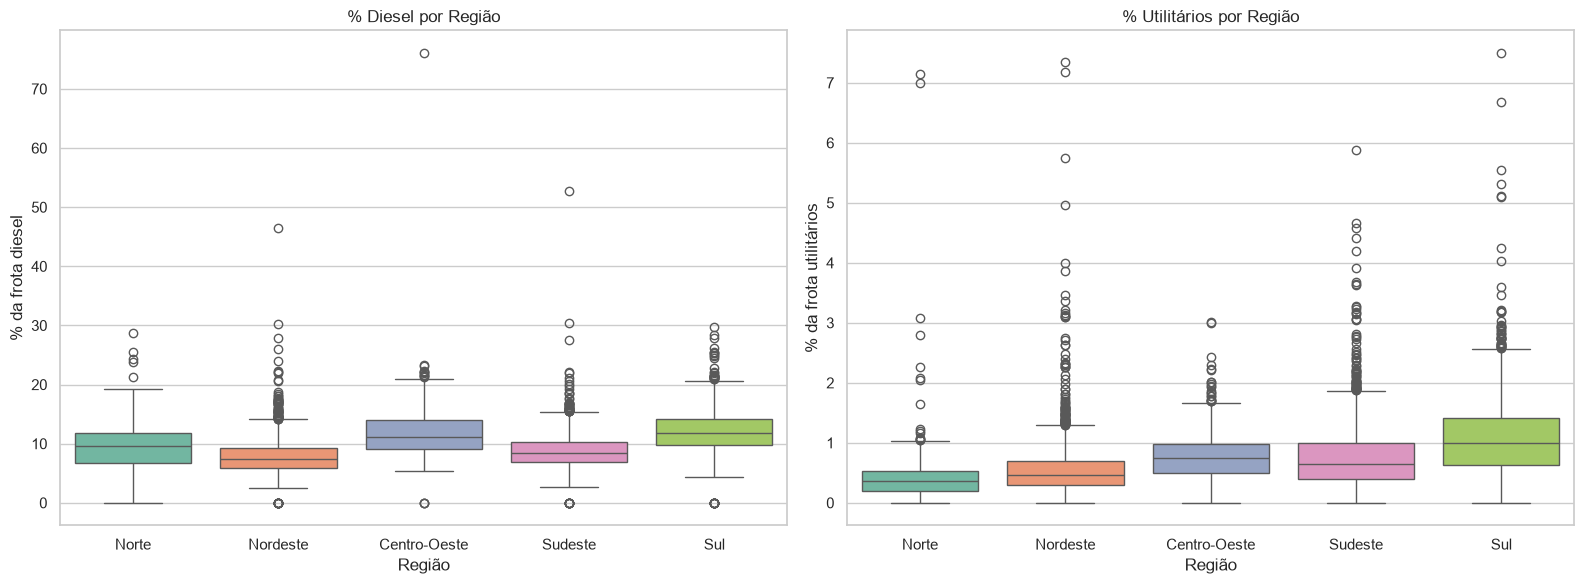


MÉDIA DE % DIESEL POR REGIÃO
               mean  median   std
regiao                           
Centro-Oeste  11.90   11.15  4.70
Nordeste       7.88    7.40  3.15
Norte          9.40    9.62  4.17
Sudeste        8.81    8.46  3.05
Sul           12.15   11.86  3.73

MÉDIA DE % UTILITÁRIOS POR REGIÃO
              mean  median   std
regiao                          
Centro-Oeste  0.80    0.74  0.42
Nordeste      0.58    0.47  0.51
Norte         0.43    0.36  0.56
Sudeste       0.77    0.65  0.57
Sul           1.12    0.99  0.71


In [7]:
# Distribuição de % Diesel e % Utilitários por Região (boxplot comparativo)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='regiao', y='target_perc_diesel', ax=axes[0],
            order=['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul'], palette='Set2')
axes[0].set_title('% Diesel por Região')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('% da frota diesel')

sns.boxplot(data=df, x='regiao', y='target_perc_utilitarios', ax=axes[1],
            order=['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul'], palette='Set2')
axes[1].set_title('% Utilitários por Região')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('% da frota utilitários')

plt.tight_layout()
plt.show()

# Estatísticas por região
print("\nMÉDIA DE % DIESEL POR REGIÃO")
print(df.groupby('regiao')['target_perc_diesel'].agg(['mean', 'median', 'std']).round(2))
print("\nMÉDIA DE % UTILITÁRIOS POR REGIÃO")
print(df.groupby('regiao')['target_perc_utilitarios'].agg(['mean', 'median', 'std']).round(2))

### Teste de Kruskal-Wallis: Variabilidade Regional do % Diesel

Para confirmar se a variabilidade regional observada nos boxplots é estatisticamente significante, aplicamos o teste não-paramétrico de Kruskal-Wallis, adequado para distribuições não-normais. A hipótese nula ($H_0$) é que a distribuição de `% diesel` é igual entre todas as regiões brasileiras.

In [8]:
# Teste de Kruskal-Wallis (comparação entre regiões para % diesel)
print("TESTE DE KRUSKAL-WALLIS: COMPARAÇÃO DO % DIESEL ENTRE REGIÕES")
print("=" * 60)
regioes_validas = df['regiao'].dropna().unique()
grupos = [df[df['regiao'] == r]['target_perc_diesel'].dropna().values for r in regioes_validas]
stat, p_val = stats.kruskal(*grupos)
print(f"Estatística de Kruskal-Wallis: {stat:.4f}")
print(f"p-value: {p_val:.4e}")
if p_val < 0.05:
    print("Conclusão: Existem diferenças regionalmente estatísticas e significativas na frota diesel (p < 0.05).")
else:
    print("Conclusão: Não existem diferenças regionais significativas (p >= 0.05).")

TESTE DE KRUSKAL-WALLIS: COMPARAÇÃO DO % DIESEL ENTRE REGIÕES
Estatística de Kruskal-Wallis: 1352.6081
p-value: 1.3052e-291
Conclusão: Existem diferenças regionalmente estatísticas e significativas na frota diesel (p < 0.05).


## Célula 5: Análise de Distribuição (Histogramas)

Histogramas com curva KDE para visualizar a forma da distribuição de cada variável. Permite identificar assimetrias, multimodalidade e concentrações.

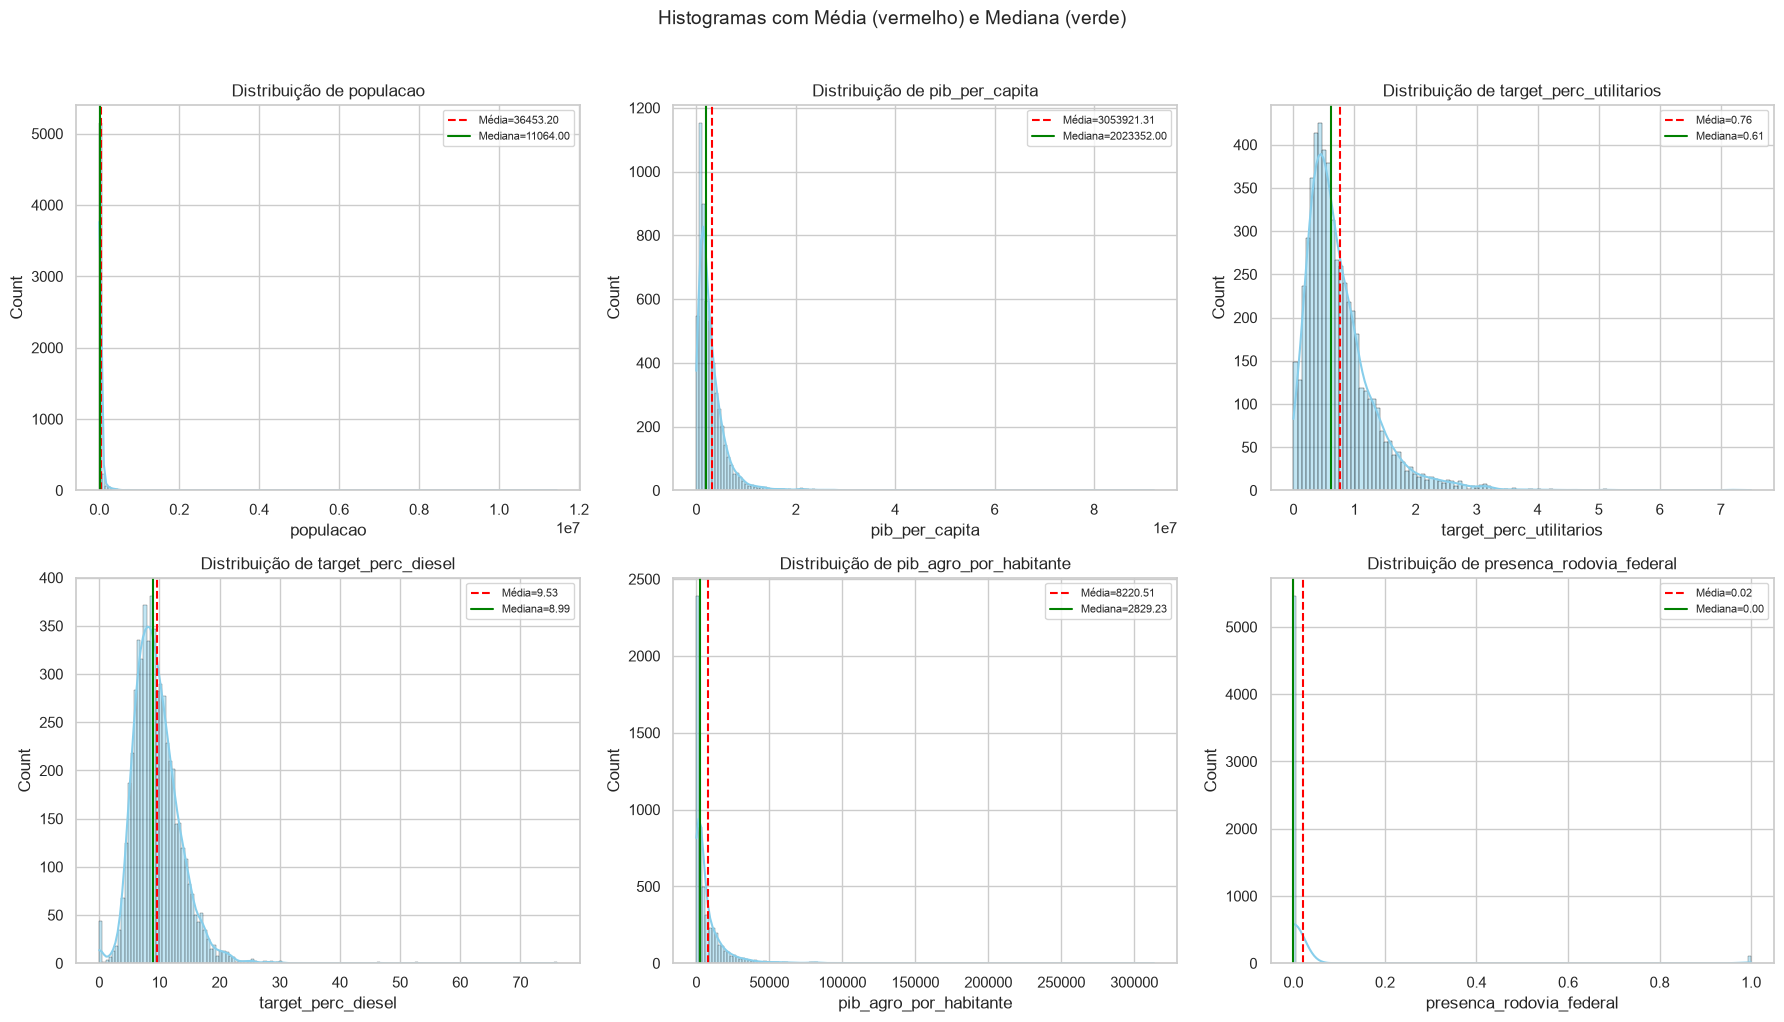

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, var in enumerate(colunas_estudo):
    ax = axes[i // 3, i % 3]
    sns.histplot(df[var], kde=True, ax=ax, color='skyblue', edgecolor='black')
    
    # Linhas de média e mediana
    media = df[var].mean()
    mediana = df[var].median()
    ax.axvline(media, color='red', linestyle='--', label=f'Média={media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', label=f'Mediana={mediana:.2f}')
    ax.legend(fontsize=8)
    ax.set_title(f'Distribuição de {var}')

plt.suptitle('Histogramas com Média (vermelho) e Mediana (verde)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Célula 6: Detecção de Outliers com Critérios Estatísticos

Aqui aplicamos dois métodos:

1. **Regra do IQR:** Outlier = valor abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR
2. **Z-Score:** Outlier = valor com |z| > 3 (mais de 3 desvios padrão da média)

Além disso, separamos **outliers reais** (anomalias) de **outliers esperados por escala** (ex: São Paulo é outlier em frota absoluta, mas isso é esperado por sua população).

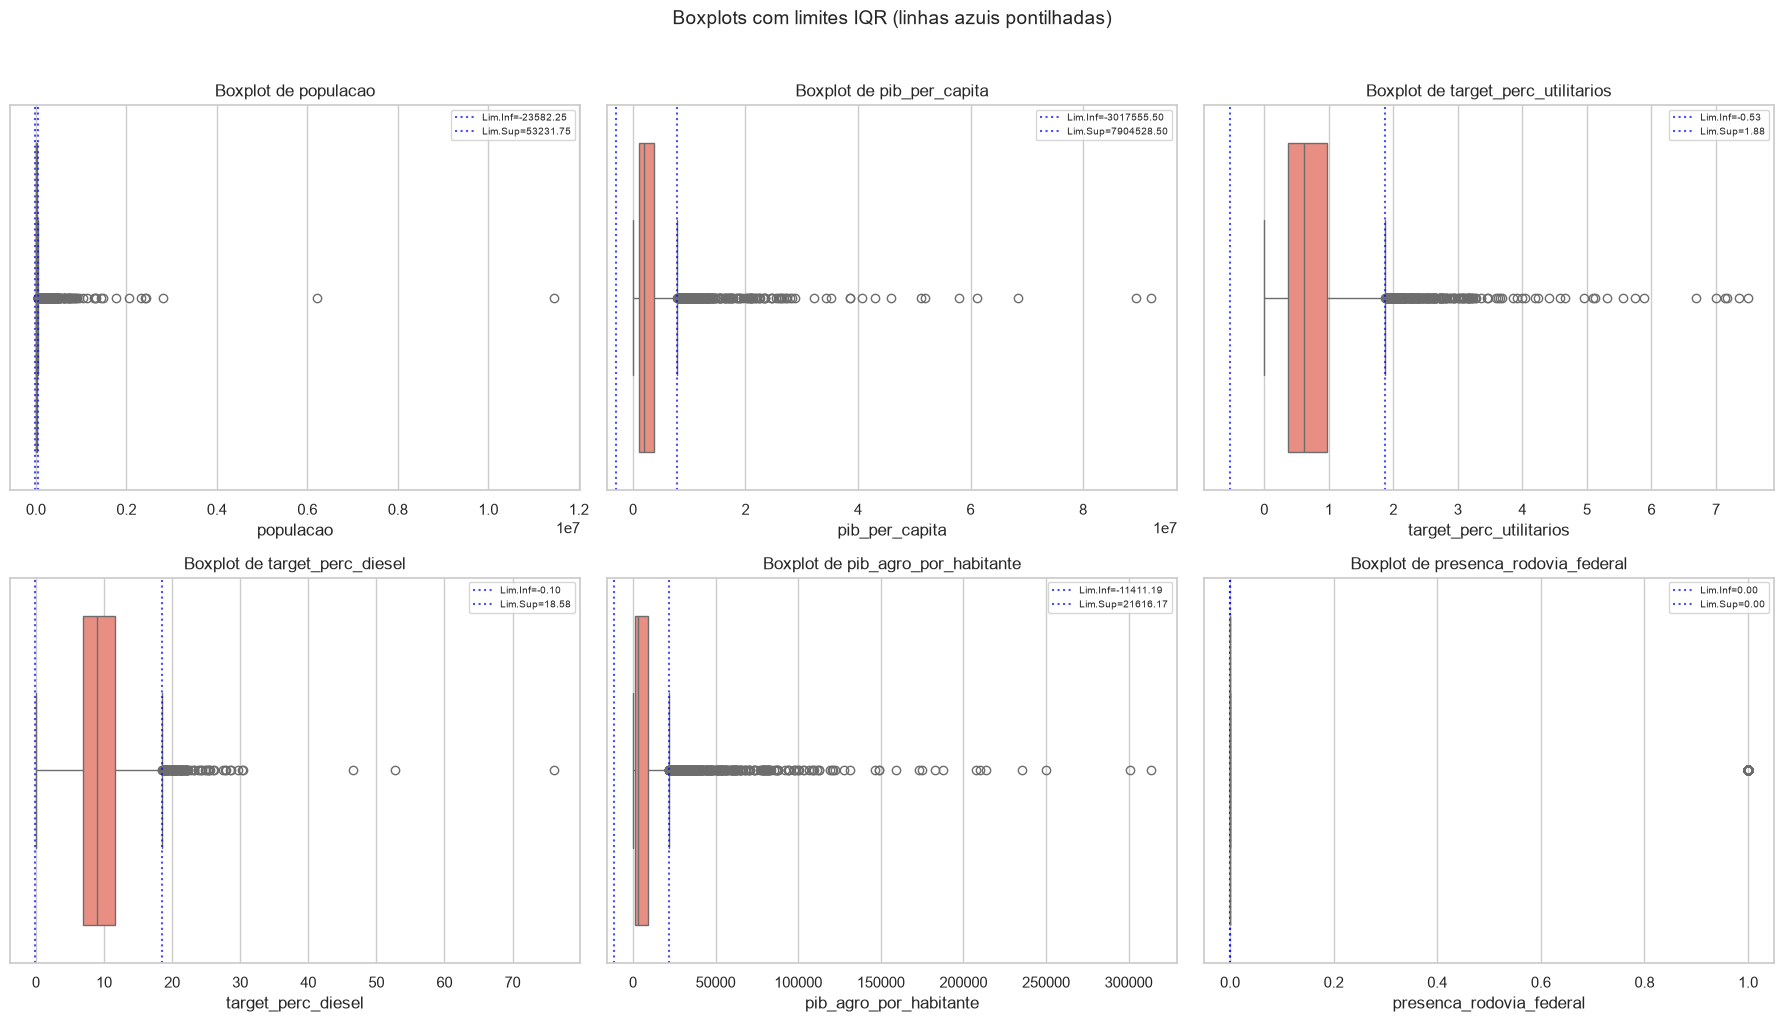


CONTAGEM DE OUTLIERS POR VARIÁVEL E MÉTODO
Variável                            |      IQR |  Z-Score | Total obs.
----------------------------------------------------------------------
  populacao                         |      605 |       30 |       5571
  pib_per_capita                    |      314 |       77 |       5571
  target_perc_utilitarios           |      248 |       89 |       5571
  target_perc_diesel                |      115 |       49 |       5571
  pib_agro_por_habitante            |      490 |      101 |       5571
  presenca_rodovia_federal          |      111 |      111 |       5571


In [10]:
# Boxplots com limites IQR
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, var in enumerate(colunas_estudo):
    ax = axes[i // 3, i % 3]
    sns.boxplot(x=df[var], ax=ax, color='salmon')
    
    # Calcular e mostrar limites IQR
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    ax.axvline(lim_inf, color='blue', linestyle=':', alpha=0.7, label=f'Lim.Inf={lim_inf:.2f}')
    ax.axvline(lim_sup, color='blue', linestyle=':', alpha=0.7, label=f'Lim.Sup={lim_sup:.2f}')
    ax.legend(fontsize=7)
    ax.set_title(f'Boxplot de {var}')

plt.suptitle('Boxplots com limites IQR (linhas azuis pontilhadas)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabela de contagem de outliers por método
print("\nCONTAGEM DE OUTLIERS POR VARIÁVEL E MÉTODO")
print("=" * 70)
print(f"{'Variável':35s} | {'IQR':>8s} | {'Z-Score':>8s} | {'Total obs.':>10s}")
print("-" * 70)

for var in colunas_estudo:
    dados = df[var]
    
    # Método IQR
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1
    outliers_iqr = ((dados < q1 - 1.5 * iqr) | (dados > q3 + 1.5 * iqr)).sum()
    
    # Método Z-Score
    z_scores = np.abs(stats.zscore(dados.dropna()))
    outliers_z = (z_scores > 3).sum()
    
    print(f"  {var:33s} | {outliers_iqr:8d} | {outliers_z:8d} | {len(dados):10d}")

In [11]:
# Análise detalhada: Top outliers em target_perc_diesel (regra IQR)
q1_diesel = df['target_perc_diesel'].quantile(0.25)
q3_diesel = df['target_perc_diesel'].quantile(0.75)
iqr_diesel = q3_diesel - q1_diesel
lim_sup_diesel = q3_diesel + 1.5 * iqr_diesel

outliers_diesel = df[df['target_perc_diesel'] > lim_sup_diesel].sort_values('target_perc_diesel', ascending=False)

print(f"OUTLIERS DE % DIESEL (acima de {lim_sup_diesel:.2f}%)")
print(f"Total: {len(outliers_diesel)} municípios")
print("=" * 80)
print(outliers_diesel[['municipio', 'uf', 'populacao', 'target_perc_diesel', 
                        'pib_agro_por_habitante', 'DIESEL', 'TOTAL']].head(10).to_string())

# Separação: outlier real vs. outlier por escala
print("\n\nCLASSIFICAÇÃO DOS OUTLIERS")
print("=" * 80)
print("OUTLIERS ESPERADOS POR ESCALA POPULACIONAL (não são anomalias):")
print("  - São Paulo (SP): maior frota absoluta do país, proporcional à população")
print("  - Capitais estaduais com PIB elevado: concentração natural de veículos")
print("\nOUTLIERS REAIS / ANOMALIAS (merecem investigação):")
print("  - Rondolândia (MT): 76% diesel — município de fronteira agrícola isolado")
print("  - Municípios com populacao=0: possível falha no merge entre bases")
print("\nVIÉS DE REGISTRO (citado na Etapa 1):")
print("  - Municípios-sede de locadoras (ex: BH) possuem frotas desproporcionais")
print("  - Veículos registrados lá não necessariamente circulam no município")

OUTLIERS DE % DIESEL (acima de 18.58%)
Total: 115 municípios
                         municipio  uf  populacao  target_perc_diesel  pib_agro_por_habitante  DIESEL   TOTAL
5294              Rondolândia (MT)  MT     3505.0           76.081425            15718.943795  1495.0  1965.0
2393                 Carmésia (MG)  MG     2605.0           52.799457             2971.508253  1556.0  2947.0
618   Santo Amaro do Maranhão (MA)  MA    13949.0           46.502976               69.300523   625.0  1344.0
3045       Taquaraçu de Minas (MG)  MG     4224.0           30.413625             1788.588542  1125.0  3699.0
585             Paulino Neves (MA)  MA    17056.0           30.230643              483.440080   367.0  1214.0
4724            Coronel Pilar (RS)  RS     1607.0           29.704510            14593.246422   382.0  1286.0
150                  Uiramutã (RR)  RR    13751.0           28.671329              629.560468    41.0   143.0
4884               Nova Pádua (RS)  RS     2343.0          

## Célula 7: Análise de Correlação (Pearson e Spearman)

Aqui apresentamos os cálculos:

- **Pearson:** mede correlação linear. Sensível a outliers e assume normalidade.
- **Spearman:** mede correlação monotônica (baseada em ranking). Mais robusta para dados assimétricos.

Quando os dados são muito assimétricos (como é o caso de população e PIB), Spearman pode capturar relações que Pearson subestima.

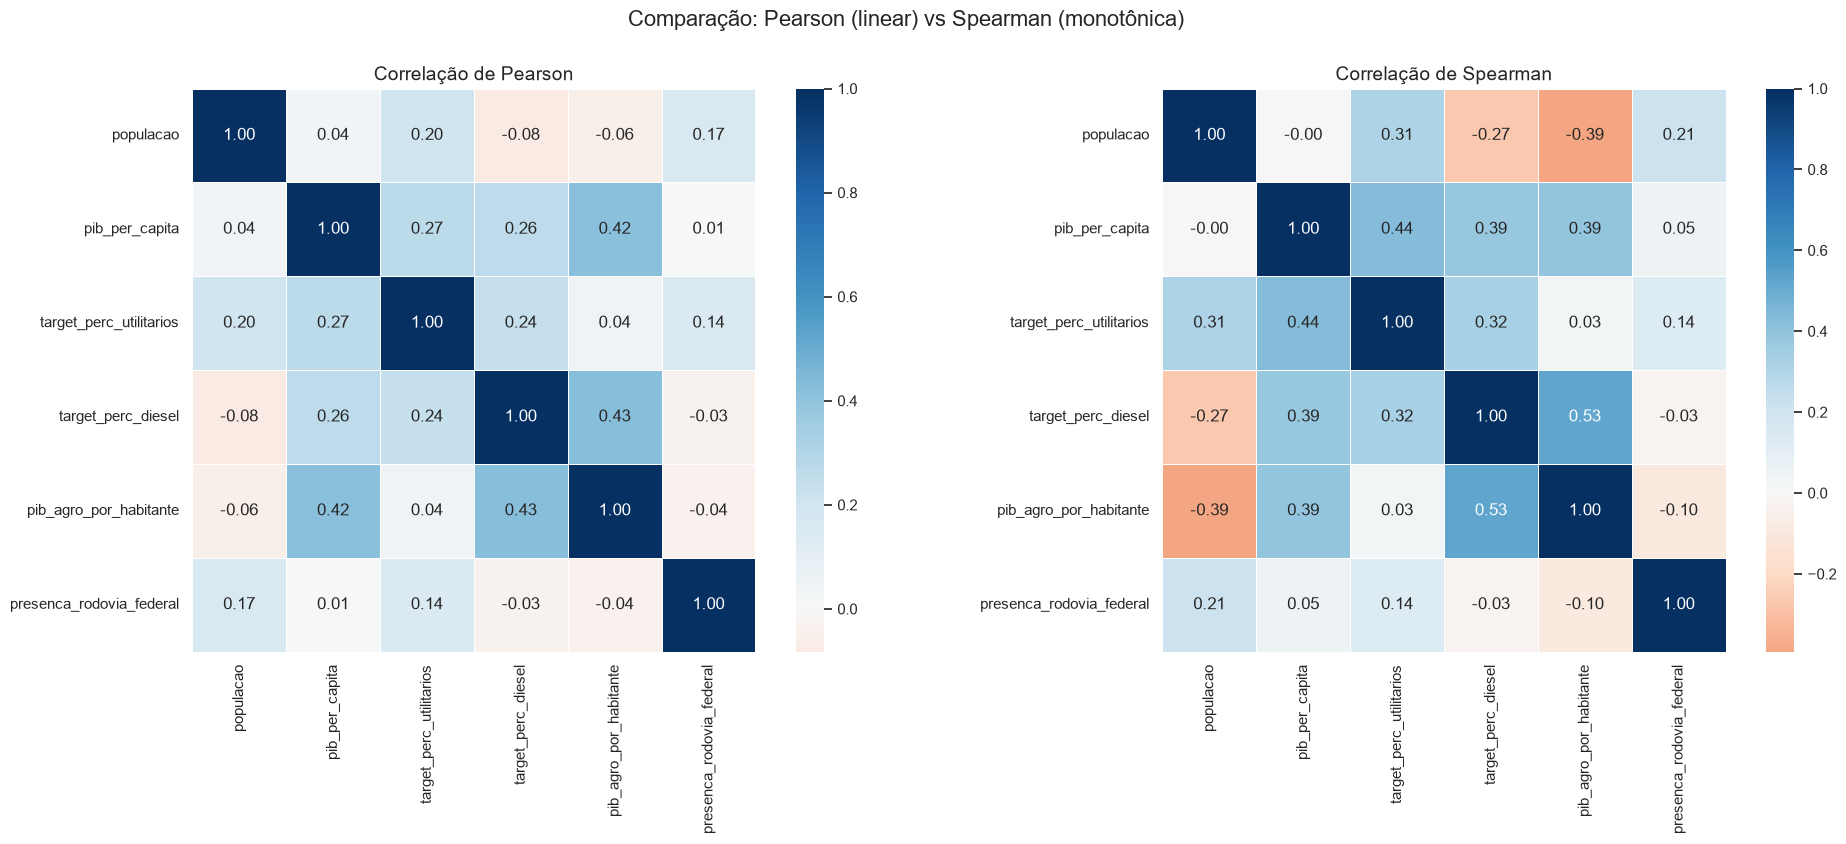


DIFERENÇAS PEARSON vs SPEARMAN (onde divergem > 0.1)
  populacao x target_perc_utilitarios:
    Pearson=0.20 | Spearman=0.31 | Diff=0.12
  populacao x target_perc_diesel:
    Pearson=-0.08 | Spearman=-0.27 | Diff=0.19
  populacao x pib_agro_por_habitante:
    Pearson=-0.06 | Spearman=-0.39 | Diff=0.33
  pib_per_capita x target_perc_utilitarios:
    Pearson=0.27 | Spearman=0.44 | Diff=0.17
  pib_per_capita x target_perc_diesel:
    Pearson=0.26 | Spearman=0.39 | Diff=0.12


In [12]:
# Matrizes de correlação lado a lado: Pearson vs Spearman
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

corr_pearson = df[colunas_estudo].corr(method='pearson')
corr_spearman = df[colunas_estudo].corr(method='spearman')

sns.heatmap(corr_pearson, annot=True, cmap='RdBu', center=0, fmt=".2f", ax=axes[0],
            square=True, linewidths=0.5)
axes[0].set_title('Correlação de Pearson', fontsize=14)

sns.heatmap(corr_spearman, annot=True, cmap='RdBu', center=0, fmt=".2f", ax=axes[1],
            square=True, linewidths=0.5)
axes[1].set_title('Correlação de Spearman', fontsize=14)

plt.suptitle('Comparação: Pearson (linear) vs Spearman (monotônica)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Diferenças relevantes entre os dois métodos
print("\nDIFERENÇAS PEARSON vs SPEARMAN (onde divergem > 0.1)")
print("=" * 60)
diff = (corr_spearman - corr_pearson).abs()
for i in range(len(colunas_estudo)):
    for j in range(i + 1, len(colunas_estudo)):
        d = diff.iloc[i, j]
        if d > 0.1:
            print(f"  {colunas_estudo[i]} x {colunas_estudo[j]}:")
            print(f"    Pearson={corr_pearson.iloc[i,j]:.2f} | Spearman={corr_spearman.iloc[i,j]:.2f} | Diff={d:.2f}")

### Testes de Significância das Correlações (Pearson e Spearman)

Calculamos os coeficientes de Pearson e Spearman associados aos p-values para verificar se as correlações identificadas na matriz são estatisticamente significativas e não mero ruído amostral.

In [13]:
# Cálculo de correlações e p-values
print("TESTES DE SIGNIFICÂNCIA DAS CORRELAÇÕES COM O % DIESEL")
print("=" * 60)
for col in ['pib_agro_por_habitante', 'pib_per_capita', 'populacao', 'densidade_demografica']:
    df_limpo = df[[col, 'target_perc_diesel']].dropna()
    p_corr, p_pval = stats.pearsonr(df_limpo[col], df_limpo['target_perc_diesel'])
    s_corr, s_pval = stats.spearmanr(df_limpo[col], df_limpo['target_perc_diesel'])
    print(f"\n{col} vs. target_perc_diesel:")
    print(f"  Pearson:  corr={p_corr:.4f} | p-value={p_pval:.4e} " + ("(Significativo)" if p_pval < 0.05 else "(Não sig.)"))
    print(f"  Spearman: corr={s_corr:.4f} | p-value={s_pval:.4e} " + ("(Significativo)" if s_pval < 0.05 else "(Não sig.)"))

TESTES DE SIGNIFICÂNCIA DAS CORRELAÇÕES COM O % DIESEL

pib_agro_por_habitante vs. target_perc_diesel:
  Pearson:  corr=0.4264 | p-value=5.4680e-245 (Significativo)
  Spearman: corr=0.5253 | p-value=0.0000e+00 (Significativo)

pib_per_capita vs. target_perc_diesel:
  Pearson:  corr=0.2644 | p-value=8.6767e-90 (Significativo)
  Spearman: corr=0.3851 | p-value=1.8857e-196 (Significativo)

populacao vs. target_perc_diesel:
  Pearson:  corr=-0.0825 | p-value=6.8374e-10 (Significativo)
  Spearman: corr=-0.2694 | p-value=2.8220e-93 (Significativo)

densidade_demografica vs. target_perc_diesel:
  Pearson:  corr=-0.1300 | p-value=1.9835e-22 (Significativo)
  Spearman: corr=-0.3331 | p-value=1.7970e-144 (Significativo)


## Célula 8: Scatter Plots — Relações entre Variáveis-Chave

Gráficos de dispersão para visualizar as relações mais relevantes para o modelo preditivo. Cada ponto é um município.

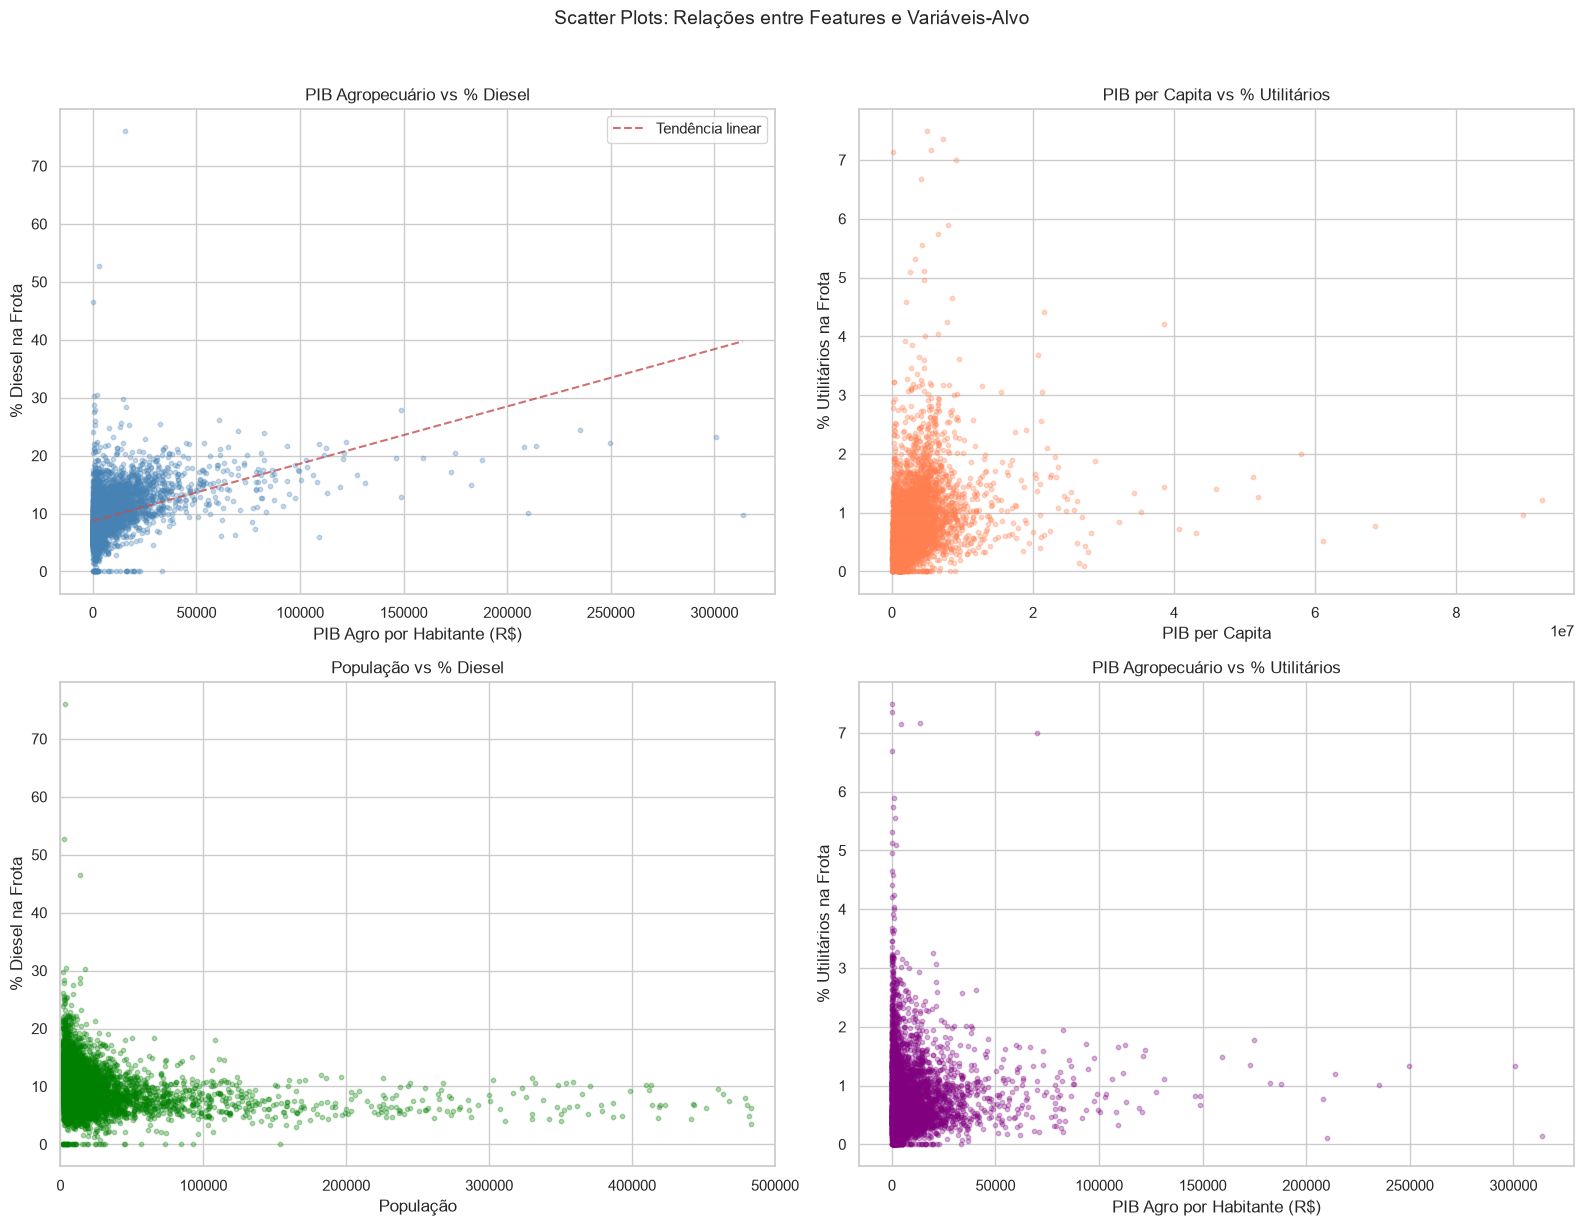

In [14]:
# Scatter plots das relações mais importantes para o modelo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. PIB Agro vs % Diesel (relação principal do projeto)
axes[0, 0].scatter(df['pib_agro_por_habitante'], df['target_perc_diesel'],
                   alpha=0.3, s=10, c='steelblue')
axes[0, 0].set_xlabel('PIB Agro por Habitante (R$)')
axes[0, 0].set_ylabel('% Diesel na Frota')
axes[0, 0].set_title('PIB Agropecuário vs % Diesel')
# Linha de tendência
z = np.polyfit(df['pib_agro_por_habitante'], df['target_perc_diesel'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['pib_agro_por_habitante'].min(), df['pib_agro_por_habitante'].max(), 100)
axes[0, 0].plot(x_line, p(x_line), "r--", alpha=0.8, label='Tendência linear')
axes[0, 0].legend()

# 2. PIB per capita vs % Utilitários
axes[0, 1].scatter(df['pib_per_capita'], df['target_perc_utilitarios'],
                   alpha=0.3, s=10, c='coral')
axes[0, 1].set_xlabel('PIB per Capita')
axes[0, 1].set_ylabel('% Utilitários na Frota')
axes[0, 1].set_title('PIB per Capita vs % Utilitários')

# 3. População vs % Diesel
axes[1, 0].scatter(df['populacao'], df['target_perc_diesel'],
                   alpha=0.3, s=10, c='green')
axes[1, 0].set_xlabel('População')
axes[1, 0].set_ylabel('% Diesel na Frota')
axes[1, 0].set_title('População vs % Diesel')
axes[1, 0].set_xlim(0, 500000)  # Limitar para ver a concentração

# 4. PIB Agro vs % Utilitários
axes[1, 1].scatter(df['pib_agro_por_habitante'], df['target_perc_utilitarios'],
                   alpha=0.3, s=10, c='purple')
axes[1, 1].set_xlabel('PIB Agro por Habitante (R$)')
axes[1, 1].set_ylabel('% Utilitários na Frota')
axes[1, 1].set_title('PIB Agropecuário vs % Utilitários')

plt.suptitle('Scatter Plots: Relações entre Features e Variáveis-Alvo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Célula 9: Considerações Éticas e LGPD na Análise Exploratória

Abaixo discutimos os riscos éticos identificados durante a análise exploratória.

### 9.1. Dados Agregados e Conformidade com a LGPD
Os dados utilizados (SENATRAN, IBGE, DNIT) são **estritamente públicos e agregados no nível municipal**. Não contêm informações pessoalmente identificáveis (PII) — sem CPF, placa, chassi ou nome de proprietário. Isso garante conformidade total com a LGPD, pois **não há risco de reidentificação**.

### 9.2. Risco de Falácia Ecológica
A análise revelou correlações entre indicadores municipais (PIB agro) e composição da frota (% diesel). Porém, é fundamental **não inferir comportamento individual a partir de dados agregados**. O correto é: *"municípios com alto PIB agropecuário tendem a ter maior proporção de diesel"*, e **não** *"pessoas ricas do agro compram diesel"*.

### 9.3. Risco de Estigmatização Regional
Os histogramas e boxplots evidenciaram grandes disparidades entre regiões (Norte/Nordeste vs. Sul/Sudeste). Ao comunicar esses resultados, é essencial evitar **interpretações que estigmatizem regiões** como "atrasadas" por terem menor frota. As diferenças refletem condições socioeconômicas estruturais, não escolhas individuais.

### 9.4. Viés de Registro (Locadoras)
Conforme identificado na Etapa 1, municípios-sede de locadoras possuem frotas desproporcionais. Usar esses dados sem tratamento pode gerar **recomendações comerciais enviesadas** (ex: sugerir abertura de concessionárias em cidades que na verdade apenas registram veículos de locadoras).

### 9.5. Transparência nas Limitações
Qualquer modelo preditivo construído sobre esses dados herda suas limitações:
- Local de registro ≠ local de circulação
- PIB de 2021, frota de 2026 (defasagem temporal)
- Municípios com dados ausentes foram preenchidos com zero (pode subestimar a frota real)

## Célula 10: Decisões de Modelagem

Aqui definimos as decisões técnicas para a próxima etapa.

### 10.1. Unidade de Análise
**Município** (5.571 registros). UF é usado apenas como atributo contextual/agrupador.

### 10.2. Variáveis-Alvo (Targets)
| Target | Descrição | Tipo de Problema |
|:---|:---|:---|
| `target_perc_diesel` | % da frota municipal que é diesel | Regressão |
| `target_perc_utilitarios` | % da frota municipal que é utilitário | Regressão |
| Cluster municipal | Agrupamento por perfil de frota | Clusterização (não supervisionado) |

### 10.3. Features Candidatas
| Feature | Justificativa | Transformação Necessária |
|:---|:---|:---|
| `pib_agro_por_habitante` | Correlação 0.43 com % diesel (mais forte encontrada) | Normalização (MinMaxScaler ou log) |
| `pib_per_capita` | Indicador de riqueza geral do município | Normalização |
| `populacao` | Proxy de urbanização | Log transform (assimetria extrema) |
| `densidade_demografica` | Indicador urbano/rural | Normalização |
| `presenca_rodovia_federal` | Polo logístico (binária) | Sem transformação |

### 10.4. Outliers a Tratar
- **Rondolândia (MT):** 76% diesel — manter e monitorar impacto no modelo
- **Municípios com pop=0:** excluir da modelagem (dados ausentes mascarados)
- **São Paulo:** outlier por escala — usar proporções (%) em vez de valores absolutos resolve

### 10.5. Hipóteses a Testar na Etapa 3
1. Municípios com maior PIB agropecuário per capita terão maior % de diesel
2. K-Means conseguirá separar "Brasis Automotivos" com perfis distintos de frota
3. Random Forest terá desempenho superior à Regressão Linear por capturar relações não-lineares